In [3]:
""" 
Solar Demon - 2026 Grad Colloquium Learning Package
=====================================================
Description: This notebook will open Solar data files, and assess when solar dorught is occuring

Version History: 30/05/26, written by Carl Doedens, 12/06/26 A.D. edit script for students

Notes:
Carl has written this code as a demonstration for honours students. Alex has run this in her notebook and removed some aspects of the code so that we may work with it.
"""

' \nSolar Demon - 2026 Grad Colloquium Learning Package\n=====================================================\nDescription: This notebook will open Solar data files, and assess when solar dorught is occuring\n\nVersion History: 30/05/26, written by Carl Doedens, 12/06/26 A.D. edit script for students\n\nNotes:\nCarl has written this code as a demonstration for honours students. Alex has run this in her notebook and removed some aspects of the code so that we may work with it.\n'

In [1]:
from pathlib import Path

In [2]:
# Data is stored in gb02, with separate directories for REZ and capital city data.
# Each file contains the full time period from August 2015 to the end of 2025 for a single region
data_dir = Path('g/data/gb02/cd3022/solar-pv/')
rez_files = [f for f in data_dir.glob('REZ/*.nc')]
city_files = [f for f in data_dir.glob('GCCSA/*.nc')]

In [3]:
# Each file contains idential coords and dims, so we can't use xr.open_mfdataset() as it won't know how to join the data.
# Instead, we open the files one by one (there are 36 in total so this doesn't take too long). 
# As the files are being opened, retrive the region name from the file name and then add it as a "region" coordinate. 
# Then once all files have been opened and have the region added as a coordinate, we can concat the datasets.

#This is a loop, it's the first loop we have come across!
# list to store datasets
ds_list = []                       #this makes an empy list that allows us to hold on to things like numbers, or objects
for file in rez_files:
    # retrieve REZ name from the file name
    rez_name = file.stem[0:2]      #this means the stem of the file, the 0-1st values of that file name 

    # open the netcdf file
    ds = xr.open_dataset(file)

    # assign the REZ name as a coordinate
    ds = ds.assign_coords({'region': rez_name})

    # add to dataset list
    ds_list.append(ds)

# exactly the same as above, but for the capital cities
for  in :
    city_name = file.stem[1:5]       #this means the stem of the file, the 1-4th values of that file name 
    
    

In [10]:
ds_list

[<xarray.Dataset> Size: 9MB
 Dimensions:  (time: 389135)
 Coordinates:
   * time     (time) datetime64[ns] 3MB 2015-07-31T18:30:00 ... 2025-12-31T11:...
     region   <U2 8B 'Q5'
 Data variables:
     actual   (time) float64 3MB ...
     ideal    (time) float64 3MB ...,
 <xarray.Dataset> Size: 9MB
 Dimensions:  (time: 389959)
 Coordinates:
   * time     (time) datetime64[ns] 3MB 2015-07-31T18:30:00 ... 2025-12-31T11:...
     region   <U2 8B 'T2'
 Data variables:
     actual   (time) float64 3MB ...
     ideal    (time) float64 3MB ...,
 <xarray.Dataset> Size: 9MB
 Dimensions:  (time: 389959)
 Coordinates:
   * time     (time) datetime64[ns] 3MB 2015-07-31T18:30:00 ... 2025-12-31T11:...
     region   <U2 8B 'Q8'
 Data variables:
     actual   (time) float64 3MB ...
     ideal    (time) float64 3MB ...,
 <xarray.Dataset> Size: 9MB
 Dimensions:  (time: 389959)
 Coordinates:
   * time     (time) datetime64[ns] 3MB 2015-07-31T18:30:00 ... 2025-12-31T11:...
     region   <U2 8B 'V5'
 Data va

In [4]:
# Now combine into a single dataset, using the new "region" coordinate as the concat dim
ds = xr.concat(
    ds_list,
    dim='region',
    coords='minimal',
    compat='override',
    join='outer',
)

In [11]:
ds

<xarray.Dataset> Size: 228MB
Dimensions:  (region: 36, time: 389959)
Coordinates:
  * region   (region) <U4 576B 'Q5' 'T2' 'Q8' 'V5' ... 'GMEL' 'GADE' 'GSYD'
  * time     (time) datetime64[ns] 3MB 2015-07-31T18:30:00 ... 2025-12-31T11:...
Data variables:
    actual   (region, time) float64 112MB nan nan nan nan ... nan nan nan nan
    ideal    (region, time) float64 112MB nan nan nan nan ... nan nan nan nan

In [5]:
"""
--------- A NOTE ON UTC TIME ------------- 
The standard time zone you find climate data in is UTC.
We (Melb, AEST) are ten hours ahead of UTC.
We must convert to work in the same time as the Australian Energy Market operator.

"""

# Change times to AEST (timezone used by AEMO)
time_utc = pd.to_datetime(ds.time.values)
time_aest = time_utc.tz_localize("UTC").tz_convert("Australia/Brisbane")
time_aest_naive = time_aest.tz_convert("Australia/Brisbane").tz_localize(None)   # removes timezone info, converts 2026-06-12 12:00:00+10:00 into 2026-06-12 12:00:00
ds = ds.assign_coords(time=("time", time_aest_naive))

# The satellite undergoes maintenance and skips a timestep once a day, so remove this time
ds = ds.where(ds['time'].dt.strftime('%H:%M') != '12:40', drop=True)

In [6]:
"""
--------- Clear Sky Index ------------- 
Carl uses CSI basically to tell us how cloudy the sky.
This is important because 1) we don't instinctly know what watts means for cloud cover and 2) because seasonality reduces watts but it can still be a clear sky
1= 100% clear, the actual solar measure is the same as the ideal 
0 = it's hella dark our there

"""

# Add CSI as a variable, by taking the ratio between the "actual" and "ideal" variables
# see /g/data/gb02/cd3022/solar-pv/README.md for more details
ds[] = ds['actual'] / ds[ideal]

# Where CSI is great than 1, flatten values to 1.
# Because CSI >= 1 indicates a clear sky, and large values can distort the norm
ds['csi'] = xr.where(ds.csi > 1, 1, ds.csi)

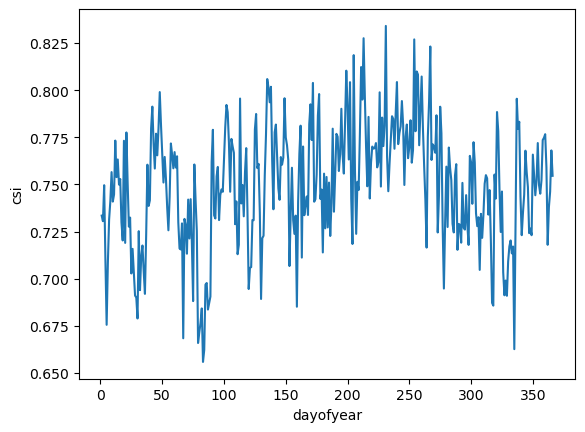

In [7]:
# Now that we have all the data laoded, here are some ways we can use it

# Annual mean national CSI:
ds.csi.groupby("time.dayofyear").mean().mean("region").plot()

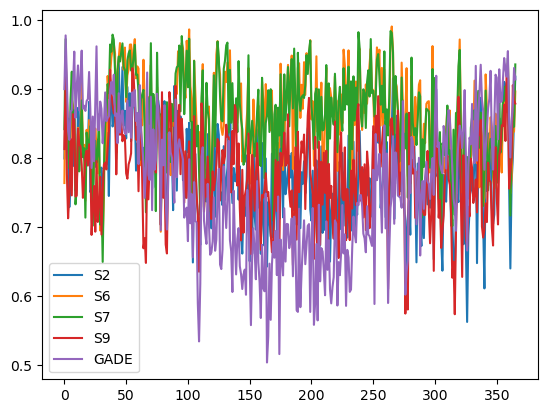

In [15]:
# Annual mean CSI for specific regions (e.g. the SA regions):

# Probably a better way of selecting by state, but given the small number of regions this rudimentary method is fine
regions = [
    'S2',
    'S6',
    'S7',
    'S9',
    'GADE'
]

plt.figure()
for reg in regions:
    csi = ds.sel(region=reg).csi
    mean_daily_csi = csi.groupby("time.dayofyear").mean()
    plt.plot(mean_daily_csi, label=reg)
plt.legend()

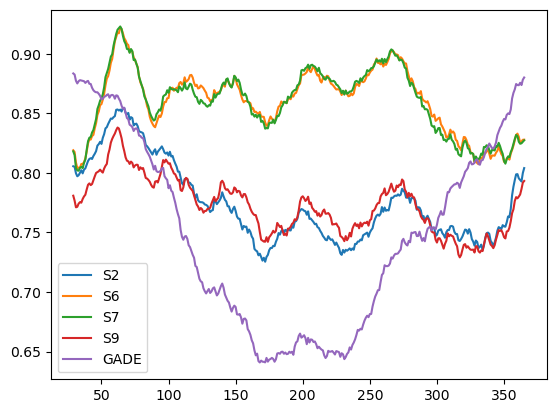

In [16]:
# Same as above, but using a running mean to smooth data
regions = [
    
]

plt.figure()
for reg in regions:
    csi 
    mean_daily_csi 
    smoothed_mean_daily_csi = mean_daily_csi.rolling(dayofyear=30).mean()
    plt.plot()
plt.legend()

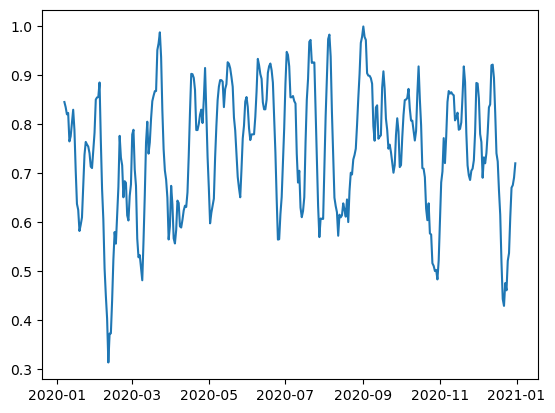

In [17]:
# Daily CSI for a single region and year
region = ''
year = ''
csi = ds.sel(region=, time=).csi
daily_csi = csi.resample(time='1D').mean()
smoothed_daily_csi = daily_csi.rolling(time=7).mean()
plt.plot(, )

In [20]:
# Some basic "solar drought/lull" definitions

# any day where a region's daily mean CSI is less than 0.5
daily = ds.resample(time='1D').mean()
csi_drought = xr.where(daily.csi < 0.5, 1, 0)

In [23]:
csi_drought

<xarray.DataArray 'csi' (time: 3806, region: 36)> Size: 1MB
array([[0, 0, 0, ..., 1, 1, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [1, 1, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0]], shape=(3806, 36))
Coordinates:
  * time     (time) datetime64[ns] 30kB 2015-08-01 2015-08-02 ... 2025-12-31
  * region   (region) <U4 576B 'Q5' 'T2' 'Q8' 'V5' ... 'GMEL' 'GADE' 'GSYD'

Text(0, 0.5, 'Proportion of regions experiencing "solar drought"')

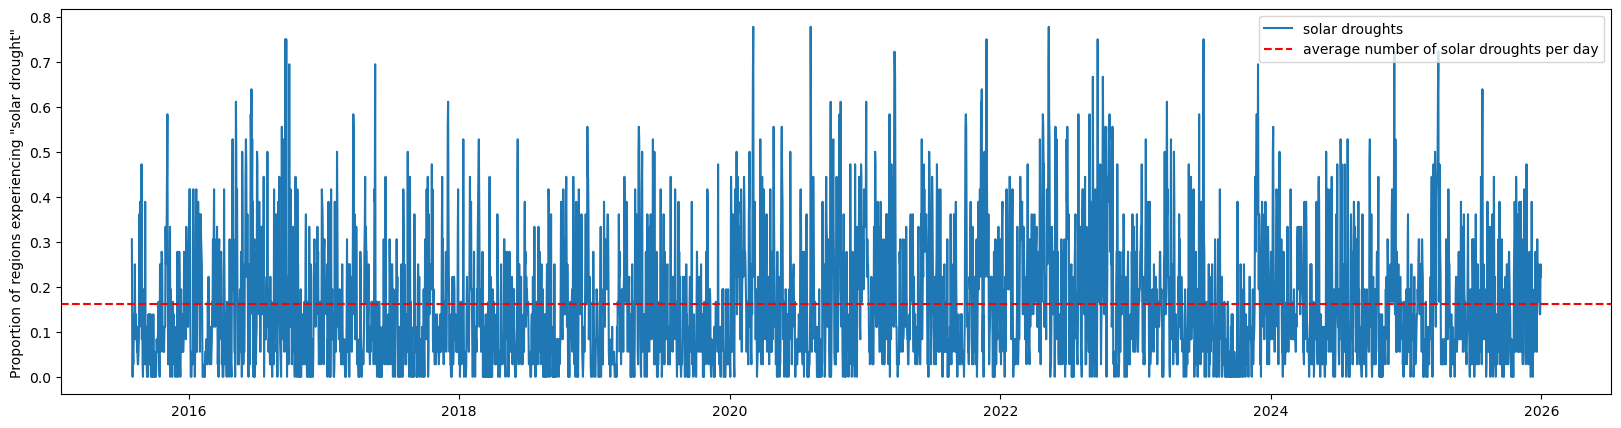

In [24]:
# add them up to get total events across all regions
csi_drought_count = csi_drought.sum('region') / len(ds.region)
mean_count = csi_drought_count.mean()

plt.figure(figsize=(20, 5))
plt.plot(csi_drought_count.time, csi_drought_count, label='solar droughts')
plt.axhline(mean_count, color='r', linestyle='--', label='average number of solar droughts per day')
plt.legend()
plt.ylabel('Proportion of regions experiencing "solar drought"')

Text(0, 0.5, 'Proportion of regions experiencing "solar drought"')

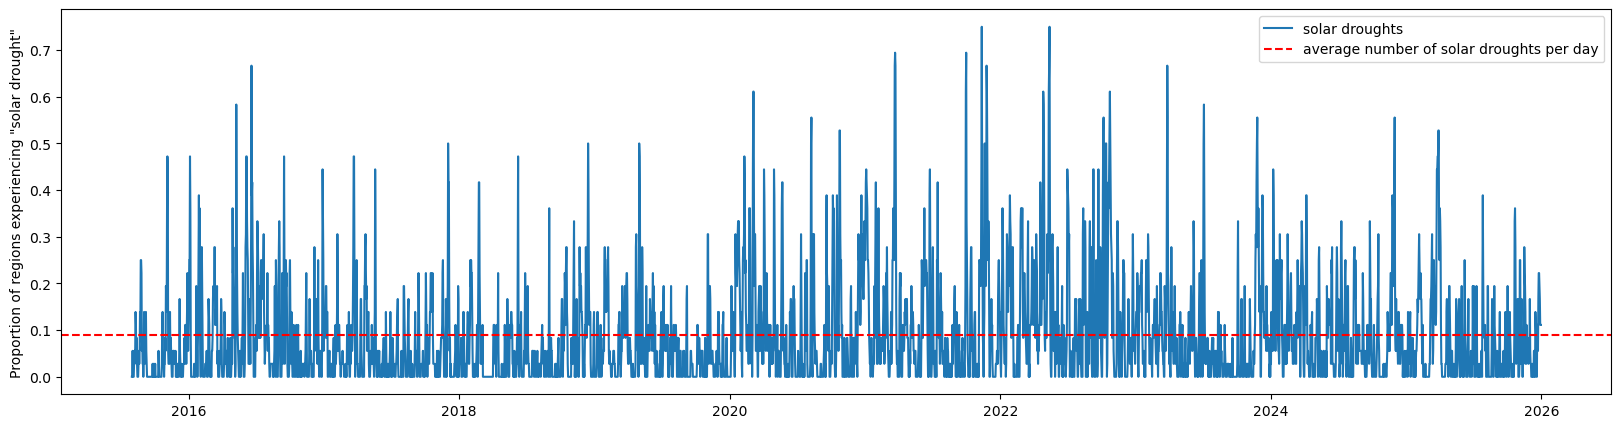

In [27]:
# Same as above, but using a running mean so the average over multiple days has to be less than 0.5

daily = ds.resample(time='1D').mean()
three_day_mean = daily.rolling(time=3).mean()
csi_drought = xr.where(three_day_mean.csi < 0.5, 1, 0)

# add them up to get total events across all regions
csi_drought_count = csi_drought.sum('region') / len(ds.region)
mean_count = csi_drought_count.mean()

# plot it

Text(0, 0.5, 'Proportion of regions experiencing "solar drought"')

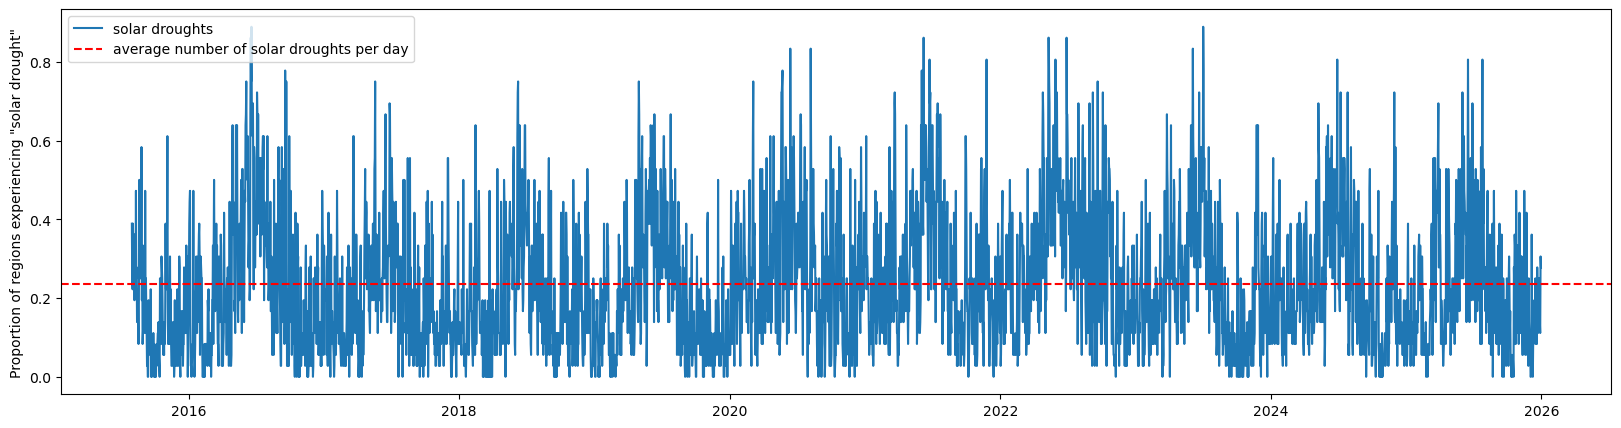

In [26]:
# Using actual energy generation as the measure instead of csi

drought_threshold = 80 # Wm-2

daily = ds.resample(time='1D').mean()
generation_drought = xr.where(daily.actual < drought_threshold, 1, 0)

# add them up to get total events across all regions
generation_drought_count = generation_drought.sum('region') / len(ds.region)
mean_count = generation_drought_count.mean()

plt.figure(figsize=(20, 5))
plt.plot(generation_drought_count.time, generation_drought_count, label='solar droughts')
plt.axhline(mean_count, color='r', linestyle='--', label='average number of solar droughts per day')
plt.legend()
plt.ylabel('Proportion of regions experiencing "solar drought"')

## Saving a CSV file

Now that we've played around with definitions of solar drought, I want use to be able to save and export datasets so that we don't have to recalculate everything everytime we use it!
Think about what variable you are actually sving, we've calculated quiet a few up above!!!

In [21]:
#Make csi_drought_count a clean new dataset where we name the variable

# da is your DataArray
da = csi_drought_count

# Create a new dataset with a new variable name
ds_new = xr.Dataset({"prop_reg_drought": da})

# Save it
ds_new.to_netcdf("/g/data/w42/ad1803/2026_Grad_Col/Data/Solar_drought/test_output.nc")

In [30]:
#Save as a CSV, first convert xr to pd
df = ds_new.to_dataframe()

# Save it 
df.to_csv("/g/data/w42/ad1803/2026_Grad_Col/Data/Solar_drought/test_output.csv")